In [5]:
import gc
import json
import os
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from transformers import AutoModel, AutoTokenizer
from transformers.models.roberta.modeling_roberta import RobertaModel
from transformers.models.roberta.tokenization_roberta import RobertaTokenizer
import torch

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint, loguniform
from sklearn.metrics import mean_squared_error, r2_score

gc.collect()
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Functions

In [2]:
def evaluate_model(model, train_data, test_datasets, title, fit=True, figsize=(10, 10)):
    """
    Train and evaluate a regression model on multiple test datasets with scatter plots.
    
    Parameters
    ----------
    model : sklearn-like regressor
        The model to train and evaluate.
    train_data : tuple
        (X_train, y_train) data for fitting if fit=True.
    test_datasets : dict
        Dictionary of test datasets: {"name": (X_test, y_test), ...}.
    title : str
        Title for the entire figure.
    fit : bool, optional
        Whether to fit the model before evaluating (default: True).
    figsize : tuple, optional
        Figure size.
    """

    X_train, y_train = train_data
    if fit:
        model.fit(X_train, y_train)

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        pearson_corr = np.corrcoef(y_test, y_pred)[0, 1]

        ax.scatter(y_test, y_pred, alpha=0.6)
        ax.plot(y_test, y_test, color='red', linestyle='--')
        ax.set_title(f"{name.upper()}\nR²={r2:.3f}, RMSE={rmse:.3f}, PCC={pearson_corr:.3f}")
        ax.set_xlabel("True pK")
        ax.set_ylabel("Predicted pK")
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.show()

### **Generate Embeddings**

In [3]:
df = pd.read_csv(r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_protein_pocket_ligands_pk.csv")
df

,pdb_id,protein_sequences,pocket_sequences,ligand_smiles,pK
0,10gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",[NH3+][C@@H](CCC(=O)N[C@@H](CSCc1ccccc1)C(=O)N...,6.397940
1,11gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",CC[C@@H](CSC[C@H](NC(=O)CC[C@H]([NH3+])C(=O)[O...,5.823909
2,13gs,['MPPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSL...,"['YFPVRGRCAA', 'VVTVETWQE', 'LK', 'QLP', 'QSN'...",O=C([O-])C1=C/C(=N\Nc2ccc(S(=O)(=O)Nc3ccccn3)c...,4.619789
3,16pk,['EKKSINECDLKGKKVLIRVDFNVPVKNGKITNDYRIRSALPTLK...,"['GR', 'AFGTAHR', 'IVGGAKVSDKI', 'IGGAMAYT', '...",Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@](=O)([O-])O[...,5.221849
4,184l,['MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAKS...,"['AV', 'GILRNAKLKPVYDSLD', 'RRAAAINMVFQMGETGVA...",CC(C)Cc1ccccc1,4.721246
...,...,...,...,...,...
18576,966c,['RWEQTHLTYRIENYTPDLPRADVDHAIEKAFQLWSNVTPLTFTK...,"['LW', 'SPFDGPGGNLAHAFQ', 'DAHFD', 'EYNLHRVAAH...",O=C(CC1(S(=O)(=O)c2ccc(Oc3ccccc3)cc2)CCOCC1)NO,7.638272
18577,9abp,['NLKLGFLVKQPEEPWFQTEWKFADKAGKDLGFEVIKIAVPDGEK...,"['FLVKQPEEPWFQTE', 'ICTPDP', 'AVDDQ', 'LVMMAA'...",OC[C@H]1O[C@H](O)[C@H](O)[C@@H](O)[C@H]1O,8.000000
18578,9hvp,['PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKP...,"['RPL', 'ALLDTGADDTVLE', 'KMIGGIGGFIKV', 'VL',...",CC(C)[C@H](N[C]([O-])OCc1ccccc1)C(=O)N[C@@H](C...,8.346787
18579,9icd,['SKVVVPAQGKKITLQNGKLNVPENPIIPYIEGDGIGVDVTPAML...,"['DGIGVDVT', 'AM', 'GPLTT', 'GGIGIAP', 'EATHGT...",Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...,3.903090


#### **ESM-2** (Protein - Sequence Embeddings)

https://huggingface.co/facebook/esm2_t30_150M_UR50D?library=transformers

In [15]:
# ESM-2 Model and Tokenizer
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t30_150M_UR50D")
model = AutoModel.from_pretrained("facebook/esm2_t30_150M_UR50D").to(device)
model.eval()

# Generate ESM-2 embeddings for protein sequences
batch_size = 8
embeddings = []
for i in tqdm(range(0, len(df), batch_size), desc="Generating ESM-2 embeddings"):
    batch_seqs = df['protein_sequences'][i:i+batch_size].tolist()
    inputs = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=1024)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.extend(batch_emb)

df['protein_embedding'] = embeddings

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Generating ESM-2 embeddings: 100%|██████████| 2323/2323 [6:40:46<00:00, 10.35s/it]  


### **MolFormer - Embeddings**
- https://arxiv.org/abs/2405.04912
- https://huggingface.co/ibm-research/MoLFormer-XL-both-10pct

In [ ]:
model = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", deterministic_eval=True, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

def get_molformer_embedding(smiles):
    inputs = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()} # Move inputs to device
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy() # Move back to CPU and convert to numpy (=> mean pooling)

# Generate embeddings
df['molformer_embedding'] = [
    get_molformer_embedding(smi) for smi in tqdm(df['ligand_smiles'], desc="Generating MoLFormer embeddings")
]

---
### **Train - Test - Split**

In [22]:
df = pd.read_pickle(r"C:\ZHAW\PA2\Sequence_based_models\2.Embeddings_ML\embeddings_ESM-2_MolFormer\PDBbind_protein_ligands_embeddings_min_MoLFormer.pkl")

#Concatenate protein and ligand embeddings
df["protein_embedding"] = df["protein_embedding"].apply(
    lambda x: np.concatenate(x) if isinstance(x, (list, np.ndarray)) and np.array(x).ndim > 1 else np.array(x)
)

df["molformer_embedding"] = df["molformer_embedding"].apply(
    lambda x: np.concatenate(x) if isinstance(x, (list, np.ndarray)) and np.array(x).ndim > 1 else np.array(x)
)
df

,pdb_id,pK,protein_embedding,molformer_embedding
0,10gs,6.397940,"[0.015475501, -0.26066357, 0.12156873, 0.09330...","[0.28744477, 0.96788037, 1.0137345, 0.85343534..."
1,11gs,5.823909,"[0.015475501, -0.26066357, 0.12156873, 0.09330...","[0.21749835, 0.2367372, 0.496767, 0.64094144, ..."
2,13gs,4.619789,"[0.02559257, -0.26755172, 0.11654376, 0.087836...","[0.5294264, 0.1726193, 0.7649629, 0.25371197, ..."
3,16pk,5.221849,"[-0.11668568, -0.07699825, -0.0073226467, -0.0...","[0.61034584, 0.34464356, 0.829178, 0.5993822, ..."
4,184l,4.721246,"[-0.05398323, -0.120338514, -0.025040016, 0.00...","[1.2403533, 0.13553013, 0.15525477, 0.58010304..."
...,...,...,...,...
18576,966c,7.638272,"[0.0075450637, -0.1324719, -0.21969323, -0.008...","[0.14021643, 0.8888316, 0.4715326, 0.09208193,..."
18577,9abp,8.000000,"[0.028716994, -0.05093946, -0.034970444, 0.077...","[0.52758294, 0.011718192, 0.28542897, 0.811083..."
18578,9hvp,8.346787,"[-0.11446372, -0.16008648, 0.087943844, 0.0421...","[0.20030321, 0.40099734, 0.38712472, 1.0730904..."
18579,9icd,3.903090,"[-0.004159363, -0.33024007, 0.24489264, 0.0704...","[0.554086, 0.40047756, 0.8294705, 0.9912925, -..."


In [23]:
# Load PDBbind original json and split into train and test sets
with open(r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_original_data_split.json", "r") as file:
    original_data_split = json.load(file)

train_ids = original_data_split["train"]

# Extract test IDs for different CASF sets
test_ids_dict = {
    "casf2013_indep": set(original_data_split.get("casf2013_indep", [])),
    "casf2016_indep": set(original_data_split.get("casf2016_indep", [])),
    "casf2013": set(original_data_split.get("casf2013", [])),
    "casf2016": set(original_data_split.get("casf2016", [])),
}

# Load PDBbind cleansplit json and split into train and test sets
with open(r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_cleansplit_data_split.json", "r") as file:
    cleansplit_data_split = json.load(file)

train_ids_clean = cleansplit_data_split["train"]
test_ids_clean = set()
for key, value in cleansplit_data_split.items():
    if key != "train":
        test_ids_clean.update(value)

print("Original split keys:", original_data_split.keys())
print("Clean split keys:", cleansplit_data_split.keys())

Original split keys: dict_keys(['casf2016', 'casf2013', 'train', 'casf2016_indep', 'casf2013_indep'])
Clean split keys: dict_keys(['casf2016', 'casf2013', 'train', 'casf2016_indep', 'casf2013_indep'])


In [25]:
# Trainingsdata original
train_df_orig = df[df["pdb_id"].isin(train_ids)]
y_train_orig = train_df_orig["pK"]

# Feature-Matrix for Original-Trainingsset => concatenate protein and ligand embeddings
X_train_orig = np.vstack(
    train_df_orig.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
)

# Testdata original 
test_datasets = {}
for key, ids in original_data_split.items():
    if key != 'train':  
        test_df = df[df["pdb_id"].isin(ids)]
        y_test = test_df["pK"]
        X_test = np.vstack(
            test_df.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
        )
        test_datasets[key] = (X_test, y_test)


In [ ]:
# Trainingsdata CleanSplit
train_df_clean = df[df["pdb_id"].isin(train_ids_clean)]
y_train_clean = train_df_clean["pK"]

# Feature-Matrix for CleanSplit-Trainingsset => concatenate protein and ligand embeddings 
X_train_clean = np.vstack(
    train_df_clean.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
)

# Testdata CleanSplit
test_datasets_clean = {}
for key, ids in cleansplit_data_split.items():
    if key != 'train': 
        test_df = df[df["pdb_id"].isin(ids)]
        y_test = test_df["pK"]
        X_test = np.vstack(
            test_df.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
        )
        test_datasets_clean[key] = (X_test, y_test)

---
### **Cross-Validation Data with specific train-validation splits**

In [27]:
# Load validation splits from JSON files
val_splits_path = r"C:\ZHAW\PA2\Sequence_based_models\val_splits"
val_split_files = [f for f in os.listdir(val_splits_path) if f.endswith(".json")]

original_files = sorted([f for f in val_split_files if f.startswith("original")])
cleansplit_files = sorted([f for f in val_split_files if f.startswith("cleansplit")])

# Load IDs from JSONs
val_splits_original = []
for file in original_files:
    with open(os.path.join(val_splits_path, file), "r") as f:
        val_data = json.load(f)
    val_splits_original.append(val_data["validation"])

val_splits_cleansplit = []
for file in cleansplit_files:
    with open(os.path.join(val_splits_path, file), "r") as f:
        val_data = json.load(f)
    val_splits_cleansplit.append(val_data["validation"])

# Map validation IDs to indices for RandomizedSearchCV
def build_cv_splits(train_df, all_val_ids_list, id_col="pdb_id"):
    """
    Converts lists of validation IDs into scikit-learn-compatible
    index tuples (train_idx, val_idx) for RandomizedSearchCV.
    """
    cv_splits = []
    id_to_idx = {pid: idx for idx, pid in enumerate(train_df[id_col])}

    for val_ids in all_val_ids_list:
        val_idx = [id_to_idx[pid] for pid in val_ids if pid in id_to_idx]
        train_idx = [idx for pid, idx in id_to_idx.items() if pid not in val_ids]
        cv_splits.append((train_idx, val_idx))

    return cv_splits

cv_splits_original = build_cv_splits(train_df_orig, val_splits_original)
cv_splits_cleansplit= build_cv_splits(train_df_clean, val_splits_cleansplit)

print(f"Original CV folds: {len(cv_splits_original)}")
print(f"CleanSplit CV folds: {len(cv_splits_cleansplit)}")

Original CV folds: 5
CleanSplit CV folds: 5


---
### **Model selection & training**

#### **Linear Regression**

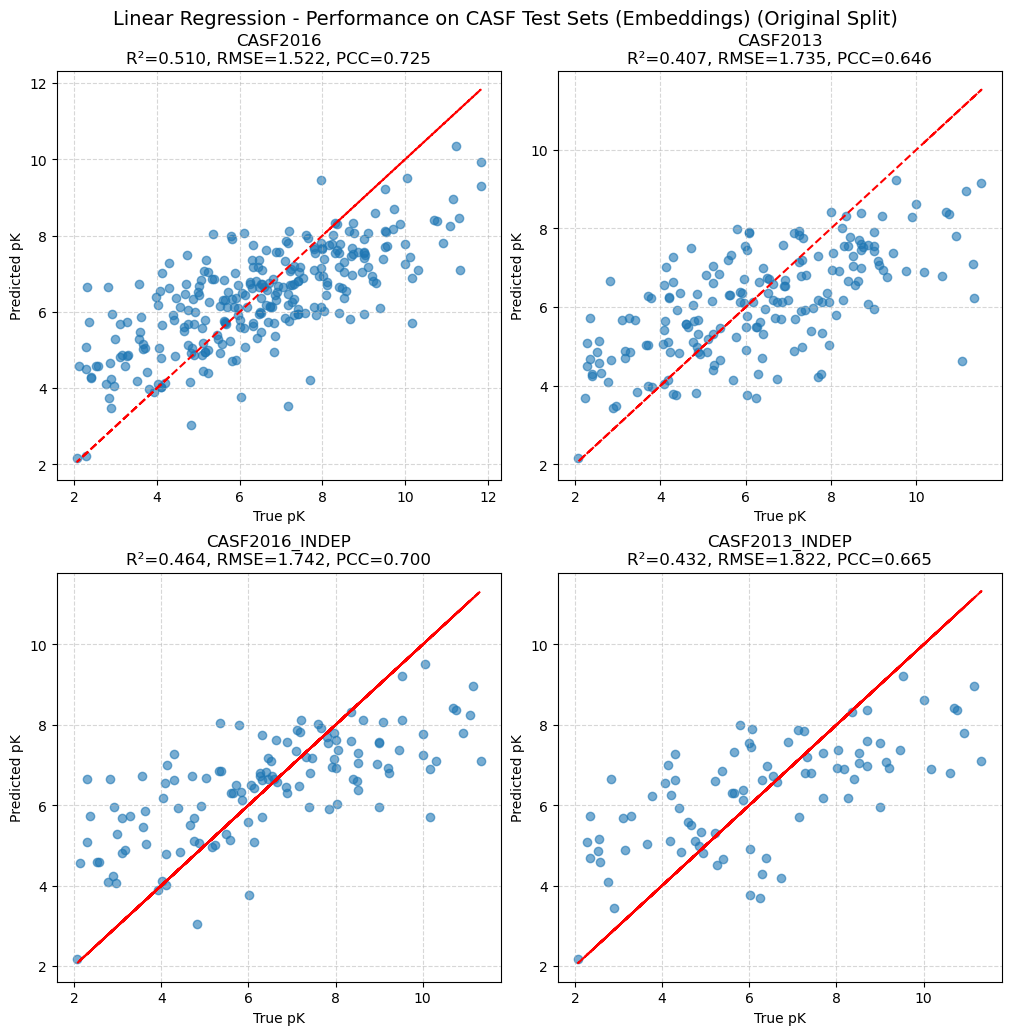

In [28]:
# Model
model = LinearRegression()

# Predict an evaluate for all test sets
evaluate_model(
    model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="Linear Regression - Performance on CASF Test Sets (Embeddings) (Original Split)",
)

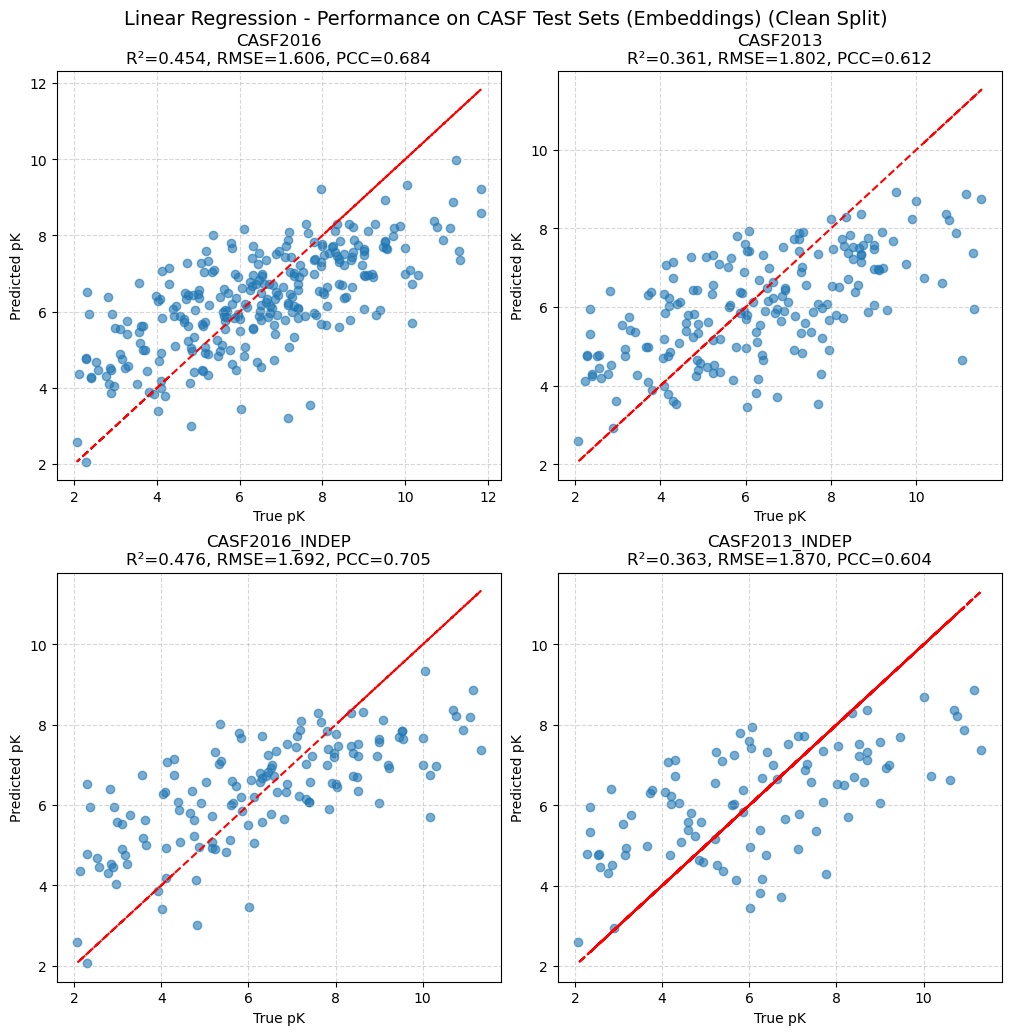

In [29]:
# Model
model_clean = LinearRegression()

# Predict and evaluate for all test sets
evaluate_model(
    model_clean,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="Linear Regression - Performance on CASF Test Sets (Embeddings) (Clean Split)",
)

---
#### **Other ML - Alogrithms (with ZHAW EarthCluster)**

In [ ]:
def evaluate_model(model, train_data, test_datasets, title, fit=True, figsize=(10, 10), save_path=None):
    X_train, y_train = train_data
    if fit:
        model.fit(X_train, y_train)

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        pearson_corr = np.corrcoef(y_test, y_pred)[0, 1]

        ax.scatter(y_test, y_pred, alpha=0.6)
        ax.plot(y_test, y_test, color='red', linestyle='--')
        ax.set_title(f"{name.upper()}\nR²={r2:.3f}, RMSE={rmse:.3f}, PCC={pearson_corr:.3f}")
        ax.set_xlabel("True pK")
        ax.set_ylabel("Predicted pK")
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=14, y=1.02)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')  # speichert das Bild
    plt.close(fig)  # schließt die Figur, spart Speicher


# --- IGNORE ---

df = pd.read_pickle("PDBbind_protein_ligands_embeddings_min_MoLFormer.pkl")

#Concatenate protein and ligand embeddings
df["protein_embedding"] = df["protein_embedding"].apply(
    lambda x: np.concatenate(x) if isinstance(x, (list, np.ndarray)) and np.array(x).ndim > 1 else np.array(x)
)

df["molformer_embedding"] = df["molformer_embedding"].apply(
    lambda x: np.concatenate(x) if isinstance(x, (list, np.ndarray)) and np.array(x).ndim > 1 else np.array(x)
)

# Load PDBbind original json and split into train and test sets
with open("PDBbind_original_data_split.json", "r") as file:
    original_data_split = json.load(file)

train_ids = original_data_split["train"]

# Extract test IDs for different CASF sets
test_ids_dict = {
    "casf2013_indep": set(original_data_split.get("casf2013_indep", [])),
    "casf2016_indep": set(original_data_split.get("casf2016_indep", [])),
    "casf2013": set(original_data_split.get("casf2013", [])),
    "casf2016": set(original_data_split.get("casf2016", [])),
}

# Load PDBbind cleansplit json and split into train and test sets
with open("PDBbind_cleansplit_data_split.json", "r") as file:
    cleansplit_data_split = json.load(file)


train_ids_clean = cleansplit_data_split["train"]
test_ids_clean = set()
for key, value in cleansplit_data_split.items():
    if key != "train":
        test_ids_clean.update(value)

# Trainingsdata original
train_df_orig = df[df["pdb_id"].isin(train_ids)]
y_train_orig = train_df_orig["pK"]

# Feature-Matrix for Original-Trainingsset
X_train_orig = np.vstack(
    train_df_orig.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
)

# Testdata original 
test_datasets = {}
for key, ids in original_data_split.items():
    if key != 'train':  
        test_df = df[df["pdb_id"].isin(ids)]
        y_test = test_df["pK"]
        X_test = np.vstack(
            test_df.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
        )
        test_datasets[key] = (X_test, y_test)

# Trainingsdata CleanSplit
train_df_clean = df[df["pdb_id"].isin(train_ids_clean)]
y_train_clean = train_df_clean["pK"]

# Feature-Matrix for CleanSplit-Trainingsset
X_train_clean = np.vstack(
    train_df_clean.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
)

# Testdata CleanSplit
test_datasets_clean = {}
for key, ids in cleansplit_data_split.items():
    if key != 'train': 
        test_df = df[df["pdb_id"].isin(ids)]
        y_test = test_df["pK"]
        X_test = np.vstack(
            test_df.apply(lambda row: np.concatenate([row["protein_embedding"], row["molformer_embedding"]]), axis=1)
        )
        test_datasets_clean[key] = (X_test, y_test)

# Load validation splits from JSON files
val_splits_path = "val_splits"
val_split_files = [f for f in os.listdir(val_splits_path) if f.endswith(".json")]

original_files = sorted([f for f in val_split_files if f.startswith("original")])
cleansplit_files = sorted([f for f in val_split_files if f.startswith("cleansplit")])

# Load IDs from JSONs
val_splits_original = []
for file in original_files:
    with open(os.path.join(val_splits_path, file), "r") as f:
        val_data = json.load(f)
    val_splits_original.append(val_data["validation"])

val_splits_cleansplit = []
for file in cleansplit_files:
    with open(os.path.join(val_splits_path, file), "r") as f:
        val_data = json.load(f)
    val_splits_cleansplit.append(val_data["validation"])

# Map validation IDs to indices for RandomizedSearchCV
def build_cv_splits(train_df, all_val_ids_list, id_col="pdb_id"):
    """
    Converts lists of validation IDs into scikit-learn-compatible
    index tuples (train_idx, val_idx) for RandomizedSearchCV.
    """
    cv_splits = []
    id_to_idx = {pid: idx for idx, pid in enumerate(train_df[id_col])}

    for val_ids in all_val_ids_list:
        val_idx = [id_to_idx[pid] for pid in val_ids if pid in id_to_idx]
        train_idx = [idx for pid, idx in id_to_idx.items() if pid not in val_ids]
        cv_splits.append((train_idx, val_idx))

    return cv_splits

cv_splits_original = build_cv_splits(train_df_orig, val_splits_original)
cv_splits_cleansplit= build_cv_splits(train_df_clean, val_splits_cleansplit)

# --- HistGradientBoosting (RSCV) ---
# Parameter grid for RandomizedSearchCV
param_dist = {
    "learning_rate": uniform(0.005, 0.05),   
    "max_iter": randint(100, 600),
    "max_depth": randint(3, 10),
    "min_samples_leaf": randint(10, 80),
    "l2_regularization": uniform(0.0, 1.0),
    "max_bins": randint(100, 255)
}

# Model with RandomizedSearchCV
# Model
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=300,
    max_depth=6,
    random_state=42
)
hgb_model.fit(X_train_orig, y_train_orig)

# Predict an evaluate for all test sets
evaluate_model(
    hgb_model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="HistGradientBoostingRegressor - Performance on CASF Test Sets (Embeddings) (Original Split)",
    save_path="plots/hist_orig_split.png"
)
#------------------------------------------------------------------------------
hgb_model = HistGradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    hgb_model,
    param_distributions=param_dist,
    n_iter=20,  
    scoring='r2',
    cv=cv_splits_original, # predefined splits 
    verbose=2, 
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train_orig, y_train_orig)

print(random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.3f}")

# Best model 
best_hgb = random_search.best_estimator_

# Predict and evaluate for all test sets
evaluate_model(
    best_hgb,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="Tuned HistGradientBoostingRegressor - Performance on CASF Test Sets (Embeddings) (Original Split)",
    save_path="plots/hist_orig_split_tuned.png", 
    fit=False
)

# Model with RandomizedSearchCV for CleanSplit
# Parameter grid for RandomizedSearchCV
param_dist = {
    "learning_rate": uniform(0.005, 0.05),
    "max_iter": randint(100, 600),
    "max_depth": randint(3, 10),
    "min_samples_leaf": randint(10, 80),
    "l2_regularization": uniform(0.0, 1.0),
    "max_bins": randint(100, 255)
}

# Model with RandomizedSearchCV

hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=300,
    max_depth=6,
    random_state=42,
    early_stopping=True
)

# Predict an evaluate for all test sets
evaluate_model(
    hgb_model,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="HistGradientBoostingRegressor - Performance on CASF Test Sets (Embeddings) (Clean Split)",
    save_path="plots/hist_clean_split.png"
)
# ------------------------------------------------------------------------------
hgb_model = HistGradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    hgb_model,
    param_distributions=param_dist,
    n_iter=20,  
    scoring='r2',
    cv=cv_splits_cleansplit, # predefined splits 
    verbose=2, 
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train_clean, y_train_clean)

print(random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.3f}")

# Best model 
best_hgb = random_search.best_estimator_

# Predict and evaluate for all test sets
evaluate_model(
    best_hgb,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="Tuned HistGradientBoostingRegressor - Performance on CASF Test Sets (Embeddings) (Clean Split)",
    save_path="plots/hist_clean_split_tuned.png", 
    fit=False
)

# --- XGBoost ---
# Model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cuda",  
    random_state=42
)

# Predict an evaluate for all test sets
evaluate_model(
    xgb_model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="XGBoost Regressor - Performance on CASF Test Sets (Embeddings) (Original Split)",
    save_path="plots/xgb_orig_split.png"
)
#------------------------------------------------------------------------------ 
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device='cuda',
    random_state=42
)

params = {
    'n_estimators': randint(300, 1200),          
    'learning_rate': loguniform(1e-3, 0.1),       
    'max_depth': randint(3, 8),                   
    'subsample': uniform(0.7, 0.3),               
    'colsample_bytree': uniform(0.7, 0.3),        
    'reg_alpha': loguniform(1e-3, 10),            
    'reg_lambda': loguniform(0.1, 50)             
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=20,                   
    scoring='r2',                
    cv=cv_splits_original,      # predefined splits 
    verbose=2, 
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train_orig, y_train_orig)
print(random_search.best_params_)
print(f"Best R²: {random_search.best_score_:.4f}")

# Best model
best_model = random_search.best_estimator_

# Predict an evaluate for all test sets
evaluate_model(
    best_model,
    (X_train_orig, y_train_orig),
    test_datasets,
    title="Tuned XGBoost Regressor - Performance on CASF Test Sets (Embeddings) (Original Split)",
    save_path="plots/xgb_orig_split_tuned.png", 
    fit=False
)
#------------------------------------------------------------------------------
# Model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cpu",  
    random_state=42
)

# Predict an evaluate for all test sets
evaluate_model(
    xgb_model,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="XGBoost Regressor - Performance on CASF Test Sets (Clean Split)",
    save_path="plots/xgb_clean_split.png"
)


# Model with RandomizedSearchCV for CleanSplit
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device='cuda',
    random_state=42
)

params = {
    'n_estimators': randint(300, 1200),          
    'learning_rate': loguniform(1e-3, 0.1),       
    'max_depth': randint(3, 8),                   
    'subsample': uniform(0.7, 0.3),               
    'colsample_bytree': uniform(0.7, 0.3),        
    'reg_alpha': loguniform(1e-3, 10),            
    'reg_lambda': loguniform(0.1, 50)             
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=20,                   
    scoring='r2',                
    cv=cv_splits_cleansplit,       # predefined splits 
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train_clean, y_train_clean)
print(random_search.best_params_)
print(f"Best R²: {random_search.best_score_:.4f}")

# Best model
best_model = random_search.best_estimator_

# Predict an evaluate for all test sets
evaluate_model(
    best_model,
    (X_train_clean, y_train_clean),
    test_datasets_clean,
    title="Tuned XGBoost Regressor - Performance on CASF Test Sets (Embeddings) (Clean Split)",
    save_path="plots/xgb_clean_split_tuned.png", 
    fit=False
)

FileNotFoundError: [Errno 2] No such file or directory: 'PDBbind_protein_ligands_embeddings_min.pkl'